<a href="https://www.kaggle.com/code/ramisasujana/mlb-2-class-7-assignment?scriptVersionId=356088620" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [4]:
uci['Occupation'].isnull().sum()

np.int64(1843)

In [5]:
replaced_by = uci['Occupation'].mode()[0]
print("Most common occupation:", replaced_by)

Most common occupation:  Prof-specialty


In [6]:
uci['Occupation'] = uci['Occupation'].fillna(replaced_by)
uci['Occupation'].isnull().sum()

np.int64(0)

# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

Skew: -0.05197899678256747


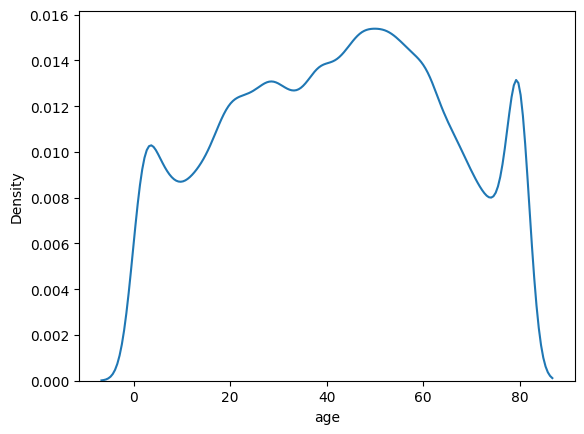

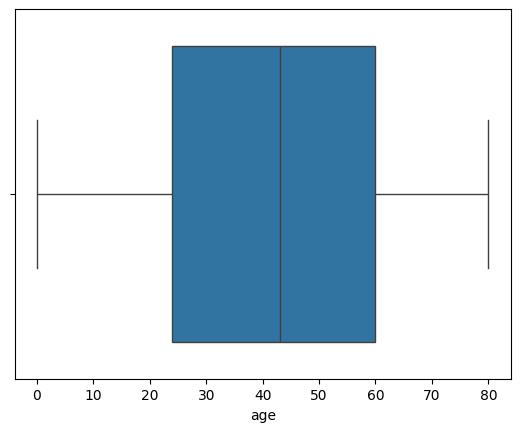

In [7]:
print("Skew:", diabetes['age'].skew())
sns.kdeplot(data = diabetes, x = 'age')
plt.show()
sns.boxplot(x = diabetes['age'])
plt.show()

In [8]:
mean = diabetes['age'].mean()
std = diabetes['age'].std()

upper = mean + 3 * std
lower = max(mean - 3 * std, 0)   

print("mean:", mean)
print("std:", std)
print("highest allowed age:", upper)
print("lowest allowed age:", lower)

mean: 41.885856
std: 22.51683987161513
highest allowed age: 109.43637561484539
lowest allowed age: 0


In [9]:
diabetes[(diabetes['age'] > upper) | (diabetes['age'] < lower)]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [10]:
print("Before trimming:", diabetes.shape)

trimmed_age = diabetes[(diabetes['age'] <= upper) & (diabetes['age'] >= lower)]

print("After trimming:", trimmed_age.shape)

Before trimming: (100000, 9)
After trimming: (100000, 9)


In [11]:
capped_age = diabetes.copy()   

capped_age['age'] = np.where(capped_age['age'] > upper, upper, np.where(capped_age['age'] < lower, lower, capped_age['age']))

print("After capping:", capped_age.shape)   
print("New max age:", capped_age['age'].max())
print("New min age:", capped_age['age'].min())

After capping: (100000, 9)
New max age: 80.0
New min age: 0.08


# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

Skew: 24.790932561757053


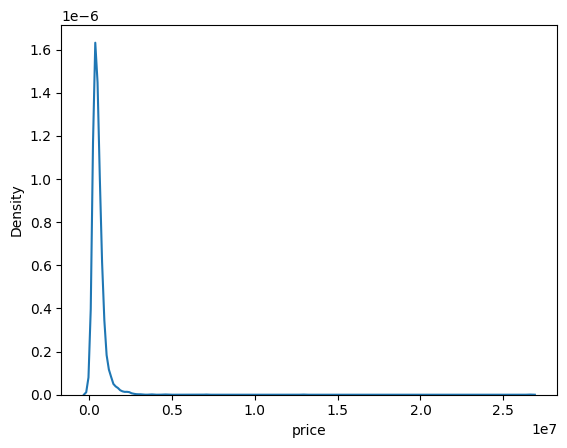

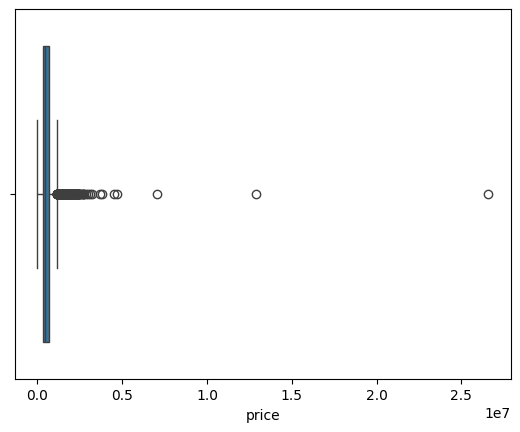

In [12]:
print("Skew:", house['price'].skew())
sns.kdeplot(data = house, x = 'price')
plt.show()
sns.boxplot(x = house['price'])
plt.show()

In [13]:
Q1 = house['price'].quantile(0.25)
Q3 = house['price'].quantile(0.75)
IQR = Q3 - Q1

upper_price = Q3 + 1.5 * IQR
lower_price = Q1 - 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper limit:", upper_price)
print("Lower limit:", lower_price)

Q1: 322875.0
Q3: 654962.5
IQR: 332087.5
Upper limit: 1153093.75
Lower limit: -175256.25


In [14]:
print("Too high:", (house['price'] > upper_price).sum())
house[house['price'] > upper_price]

Too high: 240


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
11,2014-05-02 00:00:00,1.400000e+06,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988,3838-4098 44th Ave NE,Seattle,WA 98105,USA
14,2014-05-02 00:00:00,1.200000e+06,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969,3534 46th Ave NE,Seattle,WA 98105,USA
99,2014-05-05 00:00:00,1.395000e+06,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0,3930 NE Belvoir Pl,Seattle,WA 98105,USA
122,2014-05-05 00:00:00,2.280000e+06,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2014-05-05 00:00:00,2.199900e+06,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014,19009-19021 SE 266th St,Covington,WA 98042,USA
4350,2014-07-03 00:00:00,2.659000e+07,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA
4465,2014-06-05 00:00:00,2.560498e+06,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0,2826 21st Ave W,Seattle,WA 98199,USA
4467,2014-06-06 00:00:00,1.337044e+06,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0,1415 108th Ave SE,Bellevue,WA 98004,USA


In [15]:
print("Too low:", (house['price'] < lower_price).sum())
house[house['price'] < lower_price]

Too low: 0


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country


In [16]:
print("Before trimming:", house.shape)
price_trimmed = house[(house['price'] <= upper_price) & (house['price'] >= lower_price)]
print("After trimming:", price_trimmed.shape)

Before trimming: (4600, 18)
After trimming: (4360, 18)


After capping: (4600, 18)


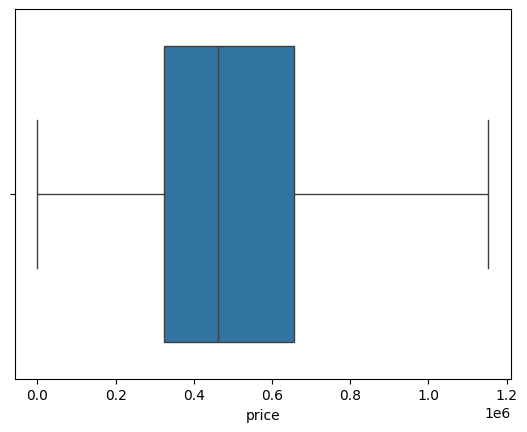

In [17]:
capped_price = house.copy()

capped_price['price'] = np.where(capped_price['price'] > upper_price, upper_price,
                        np.where(capped_price['price'] < lower_price, lower_price, capped_price['price']))

print("After capping:", capped_price.shape)   
sns.boxplot(x = capped_price['price'])
plt.show()